# CA 4.1: Data Exploration for Brain MRIs

## Objectives
1. **Set up the environment:** Import necessary libraries.
2. **Explore the BraTS dataset:** Understand the file structure, different MRI modalities, and the format of the data.
3. **Visualize the data:** Look at individual 2D slices and pixel intensity histograms to understand why preprocessing is necessary.
4. **Preprocess and Cache:** Convert the 3D NIfTI volumes into a set of 2D image slices, normalize them, and save them to disk for fast access during model training.

# 1. Setting up the environment

In [4]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import glob
from pathlib import Path
from tqdm import tqdm
import math

## Step 1: Define Data Paths

First, we define the path to the raw BraTS training data and the output directory where we will save our processed 2D slices.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = Path('/content/drive/MyDrive/brats.zip')
EXTRACT_ROOT = Path('/content/brats_data')

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset zip at: {ZIP_PATH}")

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

# Only unzip once per runtime unless the folder is empty.
if not any(EXTRACT_ROOT.iterdir()):
    !unzip -q "{ZIP_PATH}" -d "{EXTRACT_ROOT}"

print("ZIP_PATH:", ZIP_PATH)
print("EXTRACT_ROOT:", EXTRACT_ROOT)
print("Top-level extracted contents:", os.listdir(EXTRACT_ROOT)[:10])

Mounted at /content/drive
ZIP_PATH: /content/drive/MyDrive/brats.zip
EXTRACT_ROOT: /content/brats_data
Top-level extracted contents: ['BraTS2020_TrainingData', 'BraTS2020_ValidationData']


In [7]:
# Define paths for the Colab-extracted BraTS dataset
DATA_PATH = Path('/content/brats_data')

train_matches = list(DATA_PATH.rglob('MICCAI_BraTS2020_TrainingData'))
valid_matches = list(DATA_PATH.rglob('MICCAI_BraTS2020_ValidationData'))

if not train_matches:
    raise FileNotFoundError(
        f"Could not find MICCAI_BraTS2020_TrainingData under {DATA_PATH}"
    )

if not valid_matches:
    raise FileNotFoundError(
        f"Could not find MICCAI_BraTS2020_ValidationData under {DATA_PATH}"
    )

TRAIN_DATA_PATH = train_matches[0]
VALID_DATA_PATH = valid_matches[0]

OUTPUT_DIR = Path('/content/BraTS2020_Processed_Slices')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("TRAIN_DATA_PATH:", TRAIN_DATA_PATH)
print("VALID_DATA_PATH:", VALID_DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_PATH: /content/brats_data
TRAIN_DATA_PATH: /content/brats_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
VALID_DATA_PATH: /content/brats_data/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData
OUTPUT_DIR: /content/BraTS2020_Processed_Slices


## Step 2: Data Exploration & Visualization

The BraTS dataset provides multiple types of MRI scans for each patient. These are stored in the NIfTI file format (`.nii.gz` or `.nii`), which is a standard for medical imaging that stores 3D or 4D image data along with important metadata, such as voxel dimensions. We use the nibabel library to easily load these files into NumPy arrays.

Let's write a helper function to load all the scans for a single patient and then visualize a central slice from each to see how they differ.

The scan types are:
* **t1:** T1-weighted scan.
* **t1ce:** T1-weighted scan with contrast enhancement.
* **t2:** T2-weighted scan.
* **flair:** T2-weighted FLAIR scan.
* **seg:** The segmentation mask, which is our ground truth label.

In [9]:
def read_patient_niftis(patient_id: str,
                        niftis_to_load=['t1', 't1ce', 't2', 'flair', 'seg'],
                        data_path=TRAIN_DATA_PATH):
    """
    Reads images for a single patient and returns a dictionary of nifti objects.
    Handles a known file naming anomaly for patient 'BraTS20_Training_355'.
    """
    patient_image_dict = {}
    for image in niftis_to_load:
        patient_image_dict[image] = nib.load(Path(data_path, f'{patient_id}', f'{patient_id}_{image}.nii'))

    return patient_image_dict

List the training data in the data path and read in the csv files:

In [10]:
train_patients = [x for x in os.listdir(TRAIN_DATA_PATH) if '.csv' not in x]
print(f'There are {len(train_patients)} patients in the training folder')

There are 369 patients in the training folder


In [11]:
valid_patients = [x for x in os.listdir(VALID_DATA_PATH) if '.csv' not in x]
print(f'There are {len(valid_patients)} patients in the validation folder')

There are 125 patients in the validation folder


Now list only the CSV files that are available and read them in accordingly:

In [12]:
glob.glob(str(TRAIN_DATA_PATH / '*.csv'))

['/content/brats_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/survival_info.csv',
 '/content/brats_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/name_mapping.csv']

In [13]:
name_mapping_df = pd.read_csv(TRAIN_DATA_PATH / 'name_mapping.csv')
survival_info_df = pd.read_csv(TRAIN_DATA_PATH / 'survival_info.csv')

Explore the data frames below to see what they contain:

In [14]:
name_mapping_df.head()

,Grade,BraTS_2017_subject_ID,BraTS_2018_subject_ID,TCGA_TCIA_subject_ID,BraTS_2019_subject_ID,BraTS_2020_subject_ID
0,HGG,Brats17_CBICA_AAB_1,Brats18_CBICA_AAB_1,NaN,BraTS19_CBICA_AAB_1,BraTS20_Training_001
1,HGG,Brats17_CBICA_AAG_1,Brats18_CBICA_AAG_1,NaN,BraTS19_CBICA_AAG_1,BraTS20_Training_002
2,HGG,Brats17_CBICA_AAL_1,Brats18_CBICA_AAL_1,NaN,BraTS19_CBICA_AAL_1,BraTS20_Training_003
3,HGG,Brats17_CBICA_AAP_1,Brats18_CBICA_AAP_1,NaN,BraTS19_CBICA_AAP_1,BraTS20_Training_004
4,HGG,Brats17_CBICA_ABB_1,Brats18_CBICA_ABB_1,NaN,BraTS19_CBICA_ABB_1,BraTS20_Training_005


Looks like the name mapping data frame allows you to map between older versions of the BraTS dataset, the TCGA/TCIA dataset (if you wanted to look at genetic information), and tells you whether the patient was considered a high-grade glioma, or a low-grade glioma (these are outdated groupings, but for now they are ok).


In [15]:
name_mapping_df.Grade.value_counts()

,count
Grade,
HGG,293
LGG,76


In [16]:
survival_info_df.head()

,Brats20ID,Age,Survival_days,Extent_of_Resection
0,BraTS20_Training_001,60.463,289,GTR
1,BraTS20_Training_002,52.263,616,GTR
2,BraTS20_Training_003,54.301,464,GTR
3,BraTS20_Training_004,39.068,788,GTR
4,BraTS20_Training_005,68.493,465,GTR


Survival and other demographic information is contained in the survival information data frame. This might be useful if you wanted to use the images to predict an alternative endpoint instead of segmentation, for example.

Now that we know what our tabular information is in this dataset, we should take a look at what the imaging data looks like. First, let's just take a look at the format of the imaging files from one of the patients:

In [17]:
os.listdir(DATA_PATH)[:10]

['BraTS2020_TrainingData', 'BraTS2020_ValidationData']

In [18]:
os.listdir(TRAIN_DATA_PATH / 'BraTS20_Training_001')

['BraTS20_Training_001_flair.nii',
 'BraTS20_Training_001_t1.nii',
 'BraTS20_Training_001_seg.nii',
 'BraTS20_Training_001_t1ce.nii',
 'BraTS20_Training_001_t2.nii']

# 3. Loading data

* How to load the data using python packages
* How to visualize the data

Looks like these have the extension ".nii.gz", which is a common neuroimaging file format (that you may or may not have encountered in this course yet!) called "NIFTI", which actually stands for the "Neuroimaging Informatics Technology Initiative." In order to read NIFTI files using python, we need to use a specific package. Nibabel is a common one, so let's load that now:

In [19]:
import nibabel as nib # The NIFTI reader
import matplotlib.pyplot as plt # The visualizer

Nibabel has a `nib.load` function that will load NIFTI files with ease; now we just have to load and look at all of the following choices from this patient:  
* t1
* t1ce
* t2
* flair
* seg

<br> Each of these refers to the MRI scan type that was used to acquire the particular image, which will have unique image contrast when compared to one another. This should have been covered a bit in Module 0 or reviewed in your Module 2 lectures. Let's start by reading them in and visualizing them, starting with a t1 from patient 001:


In [20]:
patient_dir = TRAIN_DATA_PATH / 'BraTS20_Training_001'
t1_001_path = patient_dir / 'BraTS20_Training_001_t1.nii'

if not t1_001_path.exists():
    raise FileNotFoundError(f"Missing file: {t1_001_path}")

t1_001 = nib.load(t1_001_path)

In [21]:
# To get the image part of the nifti file format, you have to look at the ._dataobj part of the class, or use .get_fdata() function.
t1_img = t1_001.get_fdata()
# Let's get the dimensions of the image
t1_img.shape


(240, 240, 155)

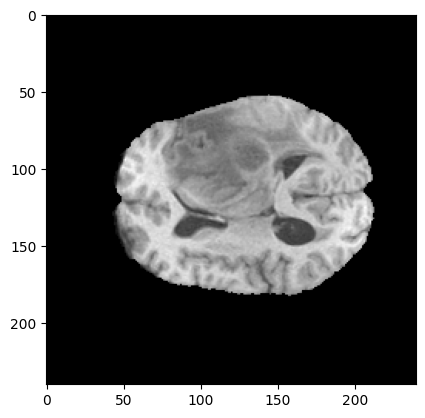

In [22]:
# To look at the file halfway through, use .shape[-1] to get the last dimension (155), and divide by 2 (rounding using //)
plt.imshow(t1_img[:,:,t1_img.shape[-1]//2], cmap = 'gray')

We are lucky - this data is really well curated and well named. We notice that there is an easy pattern to reading in the data from the file system, where the path is the same for each patient except for the patient ID and the type of image. Because of this, we can write a quick function to read in all the images from any patient into a dictionary, which will be easier to keep track of:  

In [23]:
def read_patient_niftis(
    patient_id: str,
    niftis_to_load=('t1', 't1ce', 't2', 'flair', 'seg'),
    training_or_validation='training'
):
    """
    Read NIfTI images for one BraTS patient and return a dictionary.

    Parameters
    ----------
    patient_id : str
        Short numeric ID such as '001'.
    niftis_to_load : tuple[str, ...]
        Modalities / targets to load.
    training_or_validation : str
        Either 'training' or 'validation'.
    """
    if training_or_validation == 'training':
        base_path = TRAIN_DATA_PATH
        folder_name = f'BraTS20_Training_{patient_id}'
    elif training_or_validation == 'validation':
        base_path = VALID_DATA_PATH
        folder_name = f'BraTS20_Validation_{patient_id}'
    else:
        raise ValueError("training_or_validation must be either 'training' or 'validation'")

    patient_dir = base_path / folder_name
    if not patient_dir.exists():
        raise FileNotFoundError(f"Patient directory does not exist: {patient_dir}")

    patient_image_dict = {}
    for image in niftis_to_load:
        nifti_path = patient_dir / f'{folder_name}_{image}.nii'
        if not nifti_path.exists():
            raise FileNotFoundError(f"Missing file: {nifti_path}")
        patient_image_dict[image] = nib.load(nifti_path)

    return patient_image_dict


In [24]:
## Reading in the first patient, 001, into a dictionary:
pt_img_dict = read_patient_niftis('001')

In [25]:
## Looking at the dimensions of the files. Are they all the same?
print(pt_img_dict['t1'].shape)
print(pt_img_dict['t1ce'].shape)
print(pt_img_dict['t2'].shape)
print(pt_img_dict['flair'].shape)
print(pt_img_dict['seg'].shape)

(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)
(240, 240, 155)


What does a single slice of this volume look like?

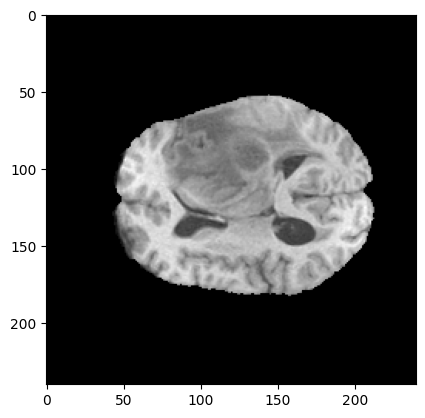

In [26]:
# Make sure the t1 is the same as before and we wrote our function correctly:
t1_img = pt_img_dict['t1'].get_fdata()
plt.imshow(t1_img[:,:,t1_img.shape[-1]//2], cmap = 'gray')

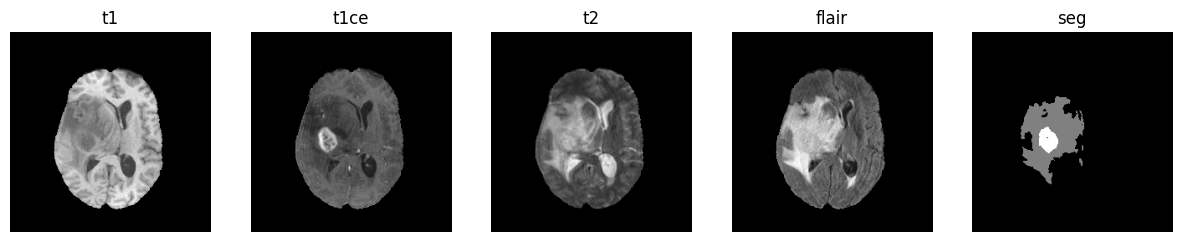

In [27]:
# Let's look at all of the types of images in the patient 001 dictionary by iterating through the dictionary

plt.figure(figsize=(15,10)) # specifying the overall grid size
for i, (key, value) in enumerate(pt_img_dict.items()): # iterates through the dictionary, while the enumerate function keeps track of the index with i
    plt.subplot(1,5,i+1)    # the number of images in the grid
    plt.imshow(value._dataobj[:, :, value.shape[-1]//2].T, cmap='gray') # Looks halfway through the volume and transposes the image so that its facing upward.
    plt.axis('off')
    plt.title(key)
plt.show()

### Understanding Pixel Intensity and Normalization

As seen in the histograms below, each MRI modality has a different range of pixel values (dynamic range). To help the neural network learn effectively, we need to scale these values to a consistent range, a process called **normalization**.

For our task, we will focus on **T2-weighted images**. We will also convert the segmentation mask into a **binary mask**, where any tumor region (values 1, 2, or 4) is mapped to 1, and the background (value 0) remains 0.


# 4. Investigating the data

* What do each of these MRI data types show with respect to brain tumors?
* Noticing patterns and differences between and among the MR images of brain tumors

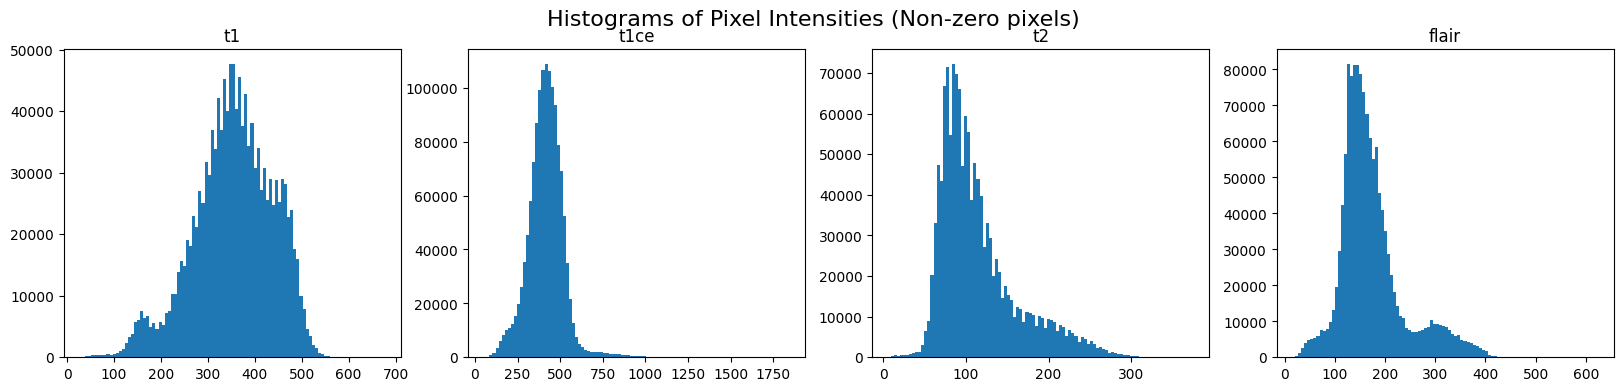

In [28]:
# Because there are so many 0s (background), it's tough to see the dynamic range of the brain tissue.
# Let's visualize the plots without the 0s.
plt.figure(figsize=(20, 4))
for i, (key, value) in enumerate(pt_img_dict.items()):
    if key == 'seg': continue # Skip segmentation mask for this plot
    plt.subplot(1, 4, i + 1)
    img_data = value.get_fdata()
    plt.hist(img_data.flatten()[img_data.flatten() != 0], bins=100)
    plt.title(key)
plt.suptitle('Histograms of Pixel Intensities (Non-zero pixels)', fontsize=16)
plt.show()

It would be helpful to visualize multiple patients at a time to get a better sense of what these values look like. Here, we're writing a function in order to visualize multiple patients at a time:

In [29]:

def visualize_nifti_volume(patient_image_dict: dict, scan_type:str='t1', visualize_every:int=1):
  """
  Takes a patient_image_dict from
  dicom_volume,  e.g. {'1': <pixel_data>, ...}
  output is to plot an appropriate size image of the voulme that one is interested in.
  """
  nifti_vol = patient_image_dict[scan_type].get_fdata()
  num_rows = math.ceil(nifti_vol.shape[2]/visualize_every/5)
  keys_sorted = range(0, nifti_vol.shape[2], visualize_every)
  plt.figure(figsize = (20, 15*num_rows))
  for i in keys_sorted: # iterates through the dictionary, while the enumerate function keeps track of the index with i
      plt.subplot(5*num_rows,5,(i)//visualize_every+1)    # the number of images in the grid
      value = nifti_vol[:,:,i].T
      plt.imshow(value, cmap= 'gray')
      plt.axis('off')
      plt.title(i)
  plt.show()

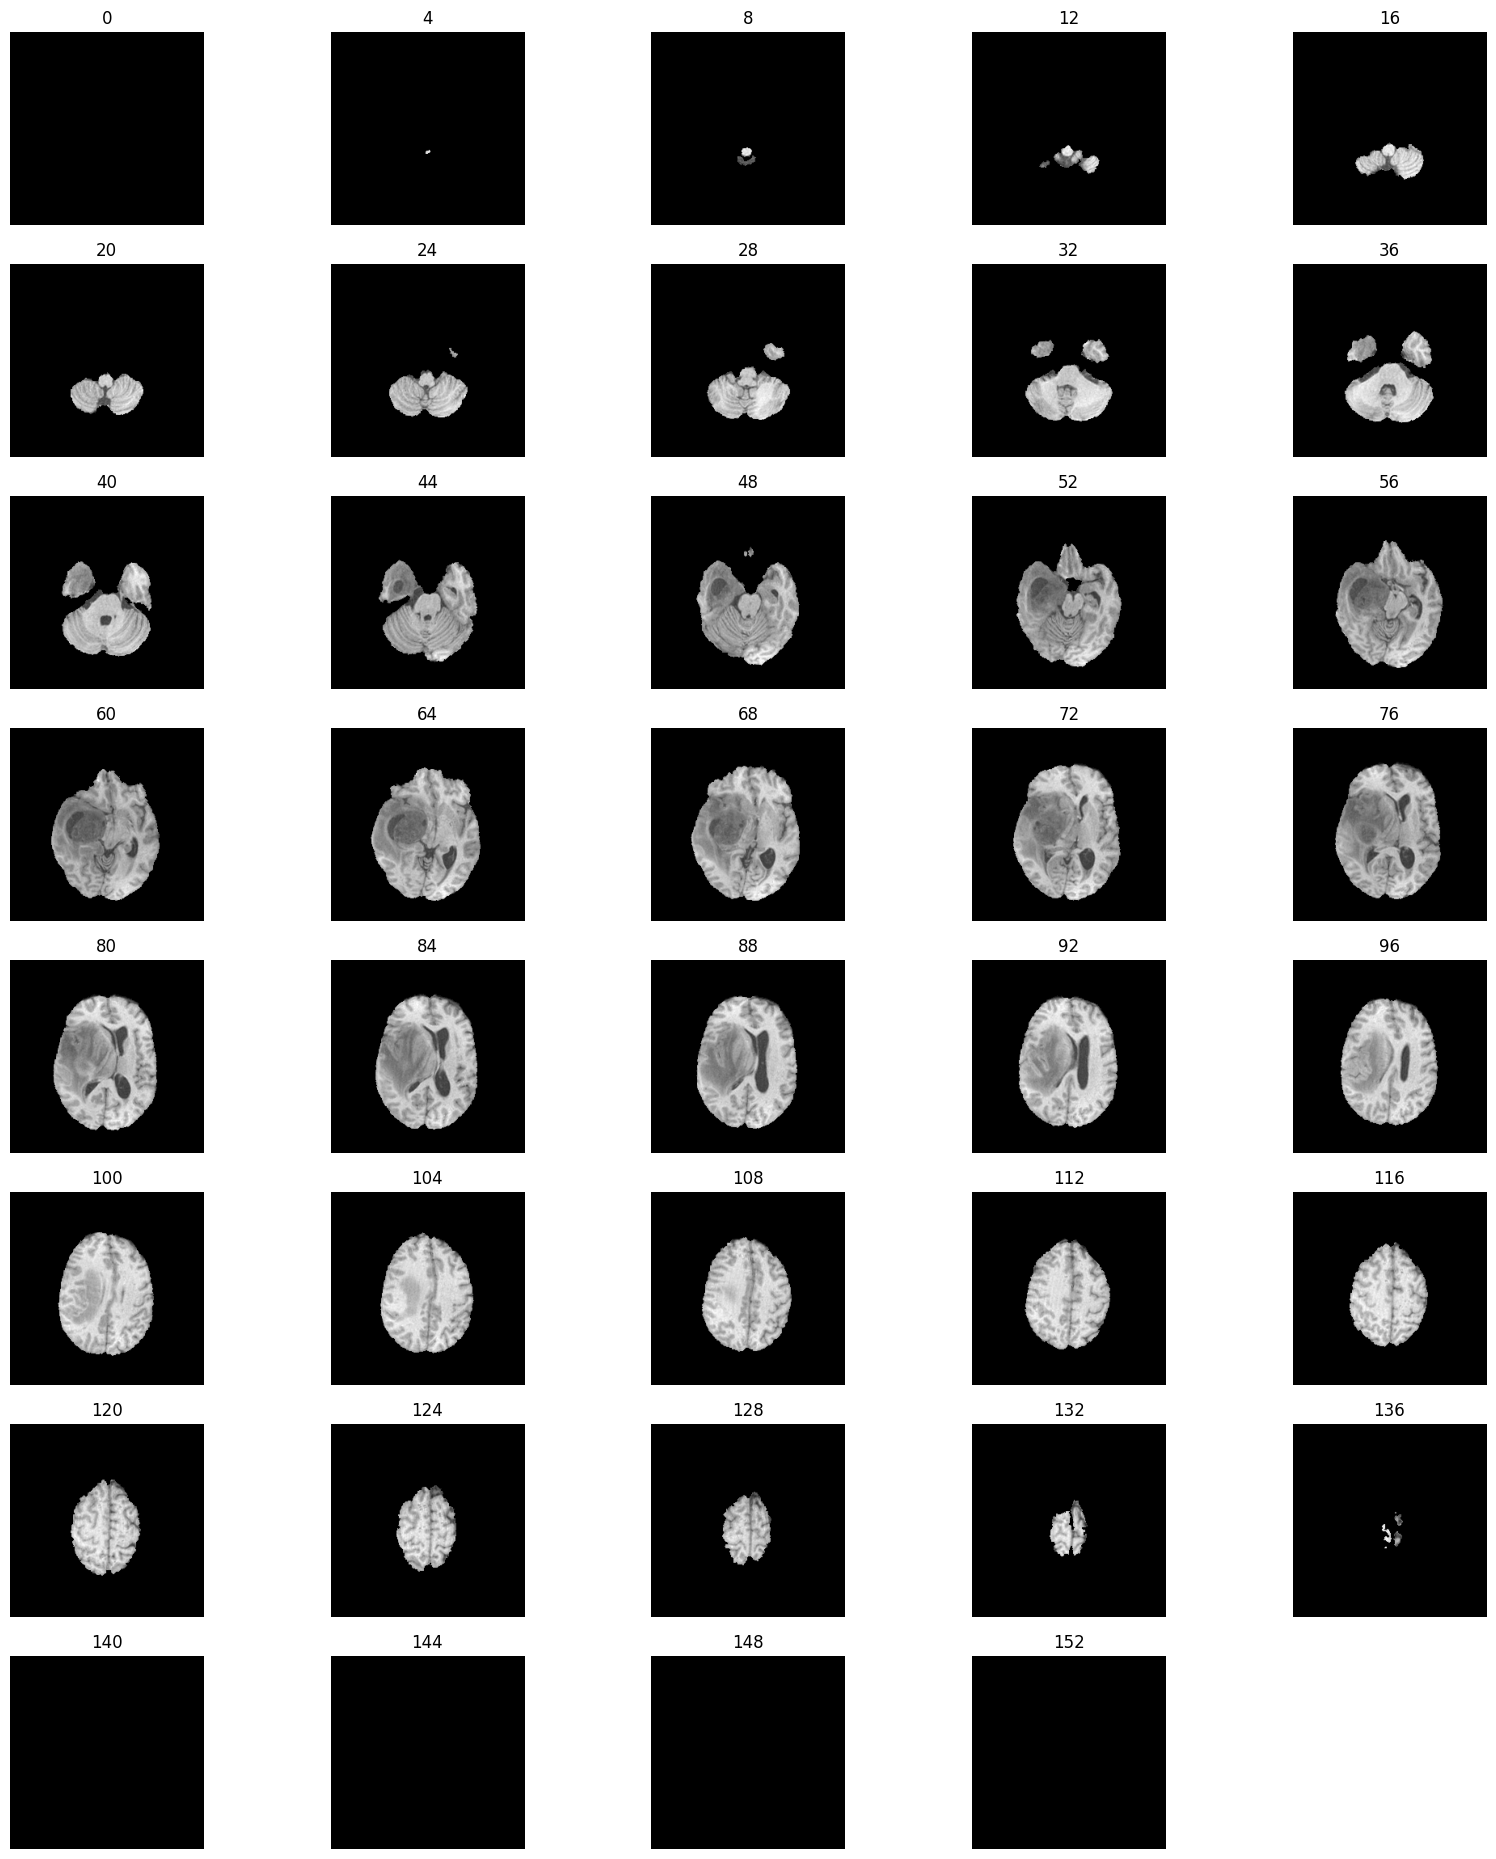

In [30]:

visualize_nifti_volume(patient_image_dict = pt_img_dict, scan_type='t1', visualize_every = 4)

In [31]:
def visualize_multiple_patients(patient_list: list):
  """
  Takes a patient list of patient_ids (strings) and visualizes them, gives them the proper titles.
  patient_list e.g. ['001', '002']
  output is to plot an appropriate size image of the patients that one is interested in.
  """
  num_rows = len(patient_list)
  for idx, patient in enumerate(patient_list):
    plt.figure(figsize = (20, 5*num_rows))
    pt_img_dict = read_patient_niftis(patient)
    for i, (key, value) in enumerate(pt_img_dict.items()):
      plt.subplot(num_rows, 5, i+1)
      img = value.get_fdata()
      plt.imshow(img[:, :, img.shape[-1]//2].T, cmap='gray')
      plt.axis('off')
      plt.title("ID: "+patient+", "+key)
    plt.show()



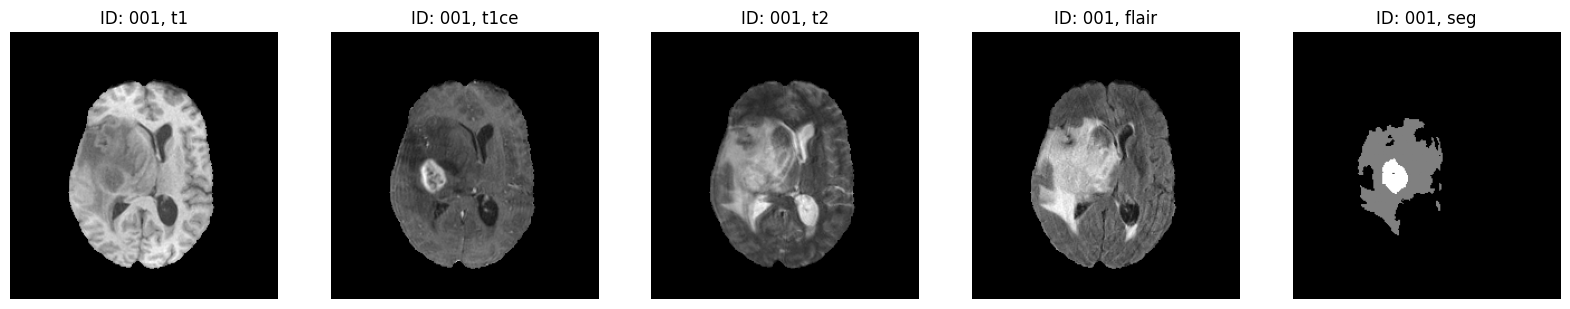

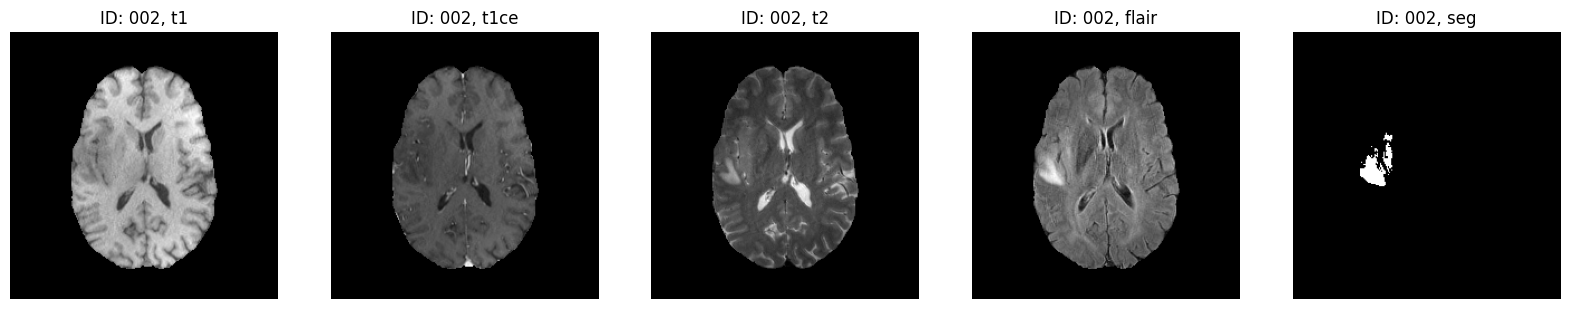

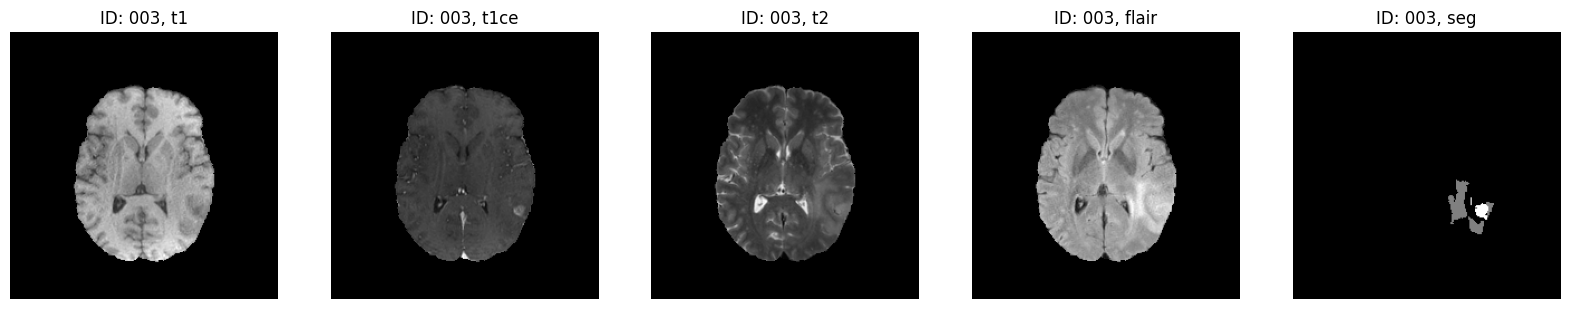

In [32]:
visualize_multiple_patients(['001', '002', '003'])

So let's take a second to notice some patterns here:

**Question 1 [1 pt]:** Are there any general patterns with brightness/contrast that you can see that some image types have?

Ans:

Yes, there are clear brightness/contrast patterns across the modalities. T1 and T1CE generally look darker overall, while T2 and FLAIR show more bright signal in and around the tumor region. The histograms also show that each modality has a different intensity distribution and dynamic range, so they are not on the same numerical scale. In other words, these scans behave like different feature channels with different contrast properties.


**Question 2 [1 pt]:** Is any image type clearly giving us different information than another?

Ans:

Yes, some image types clearly provide different information. The segmentation mask is completely different from the MRI scans because it is not an image of tissue intensity; it is a labeled target map with discrete class values. Among the MRI modalities, T1CE gives different information from T1 because the tumor’s enhancing region becomes much brighter in T1CE. FLAIR also gives different information from T2 because it makes abnormal bright tumor-related regions easier to separate from normal fluid-bright areas. So the modalities are not redundant; they emphasize different aspects of the tumor.



**Question 3 [1 pt]:** How many distinct label values does the segmentation mask contain? What does each represent?

Ans:

The segmentation mask contains 4 distinct label values: 0, 1, 2, and 4. Value 0 is background. Value 1 is the necrotic/non-enhancing tumor core. Value 2 is peritumoral edema. Value 4 is the enhancing tumor.


**Question 4 [1 pt]:** What might the relationship be between T2 and FLAIR?

Ans:

T2 and FLAIR are closely related. Both highlight similar abnormal regions, especially the edema/swelling around the tumor, but FLAIR suppresses the bright fluid signal that appears in T2. So FLAIR can be thought of as a T2-like image where normal fluid is suppressed, making tumor-related bright regions easier to isolate visually.

**Question 5 [1 pt]:** Is there a relationship between T1 and T1CE?

Ans:

Yes, I think T1CE is closely related to T1. It is essentially the T1 scan after contrast enhancement, so it highlights regions where the contrast agent accumulates. In the visualizations, this makes the enhancing part of the tumor much more obvious in T1CE than in T1.

Since there are often different ranges of intensity values in the images, let's look at the range of intensities in each of patient 001's images:

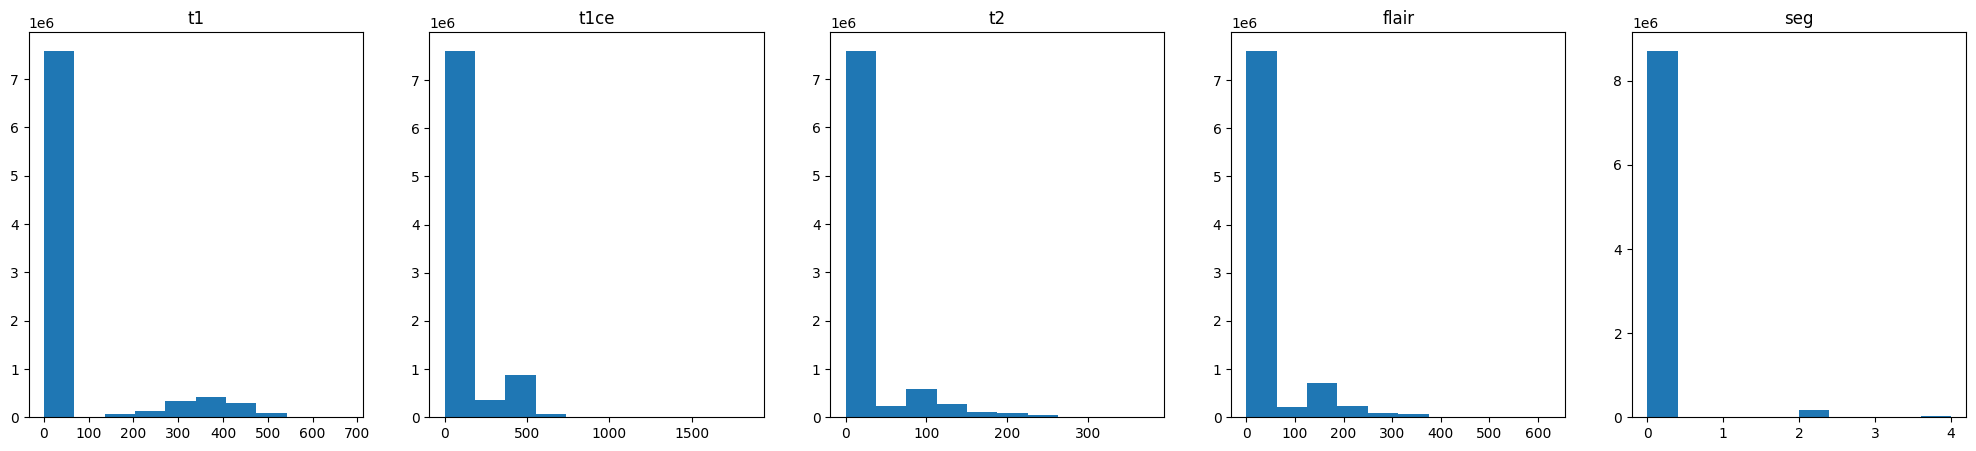

In [33]:
plt.figure(figsize=(25,5)) # specifying the overall grid size
for i, (key, value) in enumerate(pt_img_dict.items()): # iterates through the dictionary, while the enumerate function keeps track of the index with i
    plt.subplot(1,5,i+1)    # the number of images in the grid
    img = value.get_fdata()
    plt.hist(img.flatten())
    plt.title(key)
plt.show()

Because there are so many 0s, it's tough to look at the dynamic range of the intensity values. Let's just visualize the plots without the 0s.

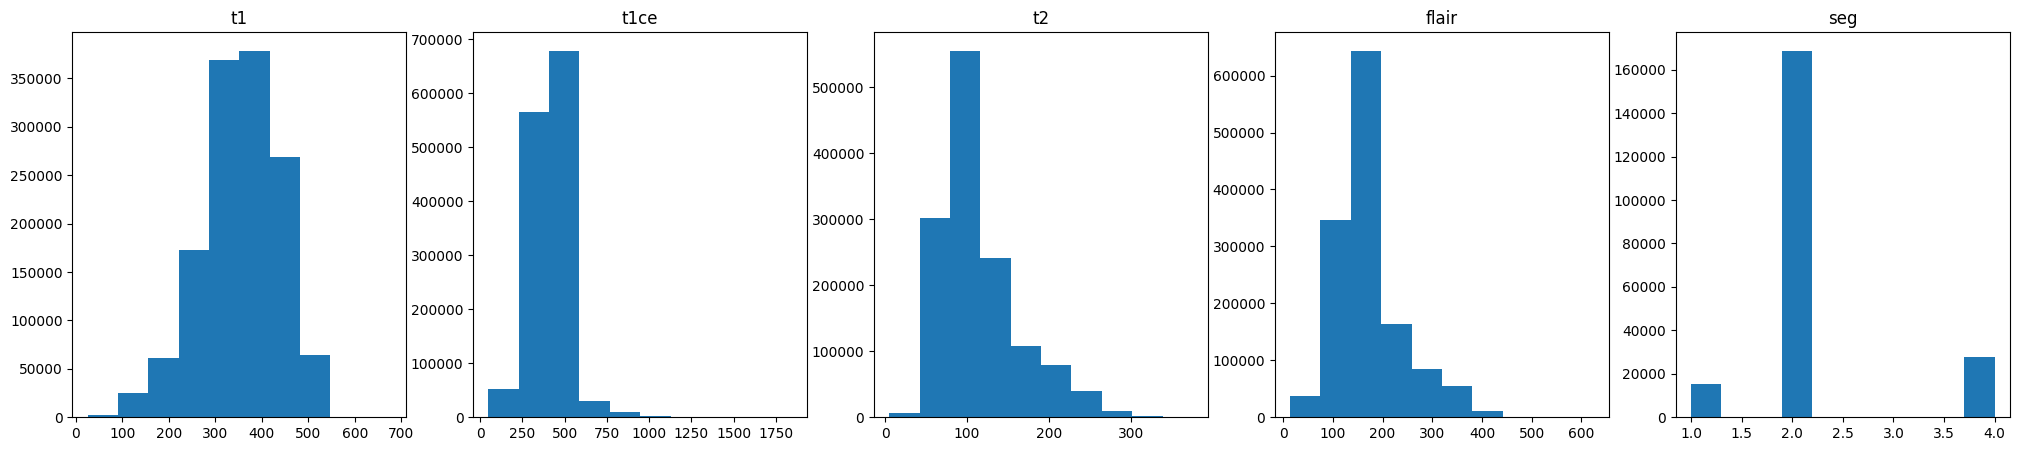

In [34]:
plt.figure(figsize=(25,5)) # specifying the overall grid size
for i, (key, value) in enumerate(pt_img_dict.items()):
    plt.subplot(1,5,i+1)
    img = value.get_fdata()
    plt.hist(img.flatten()[img.flatten()!=0])
    # plt.xlim(0, 2000)
    plt.title(key)
plt.show()

The range of the MRI pixel values is called the "dynamic range". We can see that it's different for each type of image. Specifically:
* T1's maximum: 700
* T1CE's maximum: 1750
* T2's maximum: 300
* FLAIR's maximum: 600
* SEG's maximum: 4


**Question 6 [1 pt]:** Can you think of why it might be an issue for a deep learner to deal with so many dynamic ranges if we read these in raw?

Ans:

This is a problem for a deep learning model because the input channels have very different dynamic ranges. If we feed the raw values directly into a model, channels with larger magnitudes can dominate the optimization process, while lower-range channels may be underweighted even if they contain useful information. This is a feature-scaling problem: uneven input scales can make training less stable and make it harder for the model to learn balanced representations across modalities.

**Question 7 [1 pt]:** How might we be able to solve that issue?

Ans:

We can solve this by normalizing or standardizing the input images before training. For example, we could scale each modality to a common range such as [0, 1], or apply z-score normalization per modality. The goal is to put all channels onto a comparable scale so the model can learn from each one more fairly and train more stably.

The segmentation is a special case, because there are 3 different segments in there. Let's look at those a little more closely.

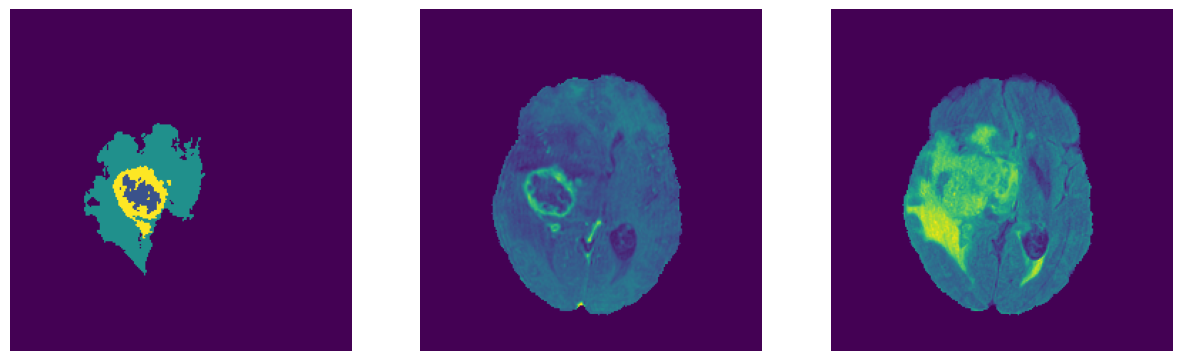

In [35]:
## I cycled through a few of the slices to find one (71) that shows the 3 different tumor segments.
slice_number = 71
plt.figure(figsize=(15,5)) # specifying the overall grid size
for i, img_type in enumerate(['seg', 't1ce', 'flair']):
  plt.subplot(1, 3,i+1)
  img = pt_img_dict[img_type].get_fdata()
  plt.imshow(img[:,:,slice_number].T)
  plt.axis('off')
plt.show()

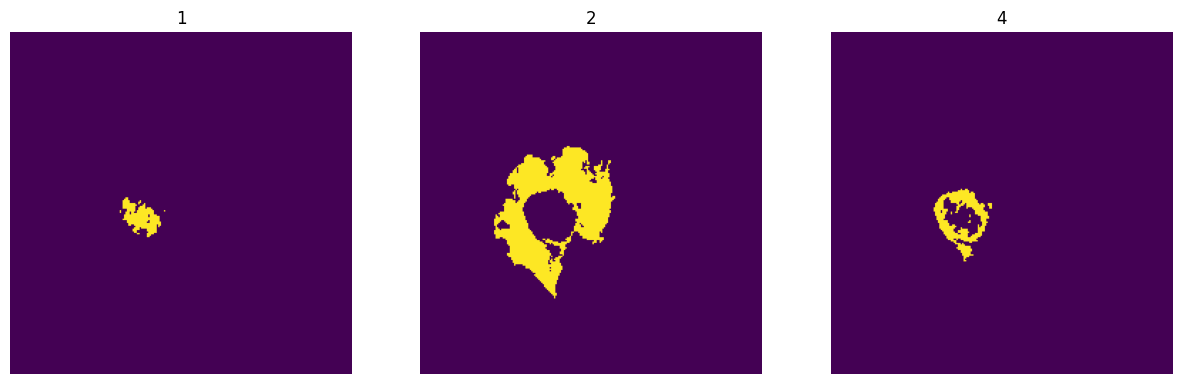

In [36]:
## We saw from the histogram that the values are either 0, 1, 2, or 4.
## Look at what each of these represent
slice_number = 71
plt.figure(figsize=(15,5)) # specifying the overall grid size
for i, img_type in enumerate(['seg', 'seg', 'seg']):
  plt.subplot(1, 3,i+1)
  img = pt_img_dict[img_type].get_fdata()
  if i <2:
    plt.imshow(img[:,:,slice_number].T == i+1)
    plt.axis('off')
    plt.title(str(i+1))
  else:
    plt.imshow(img[:,:,slice_number].T == 4)
    plt.axis('off')
    plt.title('4')
plt.show()

From the previous two cells, we can conclude which segmentation each of the 1s, 2s, and 4s represent. Answer the following questions:

**Question 8 [1 pt]:** What are the names of each of these regions?

Ans:

- Necrotic/non-enhancing (dead) tumor core
- Peritumoral (swollen) edema
- Enhancing (actively-growing) tumor


**Question 9 [1 pt]:** Which number corresponds to which region?

Ans:

1 -> Necrotic/non-enhancing tumor core

2 -> Peritumoral edema

4 -> Enhancing tumor

### 5. Play around and explore.

1. Pick the patients with the longest and shortest survival and look at their tumors.
2. Do you notice any difference?

### 6. Why is the data so perfect?

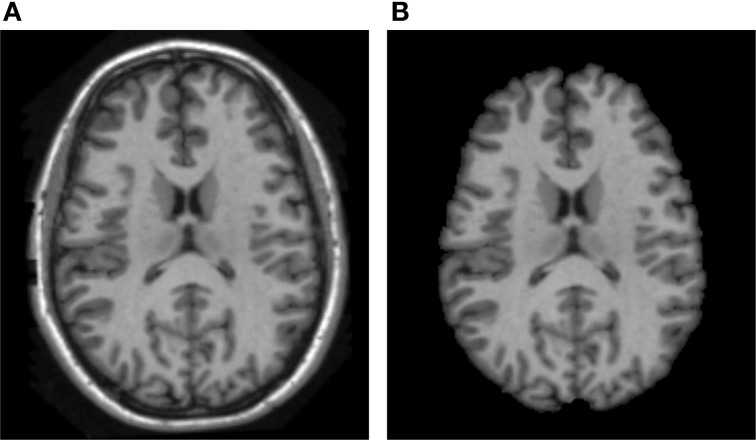

You might notice that all our data looks like (B), but in fact it originally was like (A).

* (A) contains the skull - (B) has gone through a process called skull stripping.
* In fact, the data we are working with has gone through a LOT of preprocessing. What does that look like?

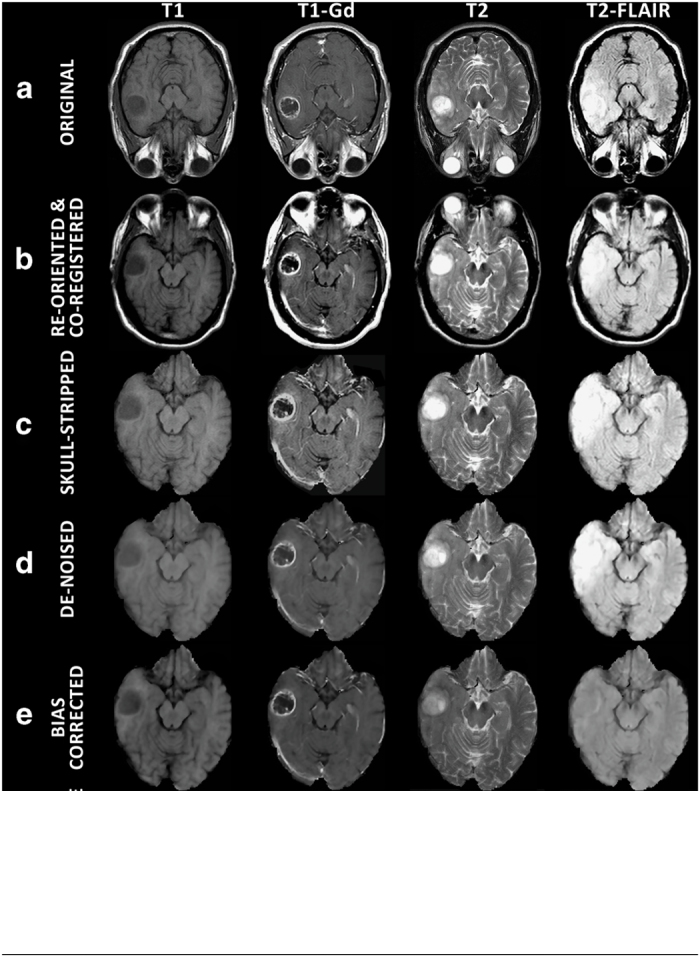

Looking at the above processing steps - let's be thankful that we don't have to do all that ourselves!
**Question 10 [1 pt]:**  Can you describe the visual differences between each step?

Ans:

Yes, each preprocessing step causes a clear visual change:

- Original: The scans still include non-brain structures such as the skull and surrounding tissue. The images also look less standardized across modalities.
- Re-oriented and co-registered: The brain is aligned into a common orientation and position, so the same anatomical region appears in a more consistent location across T1, T1-Gd, T2, and T2-FLAIR.
- Skull-stripped: The skull and other non-brain tissue are removed, so only the brain remains visible.
- De-noised: The images look smoother and less grainy, with less high-frequency visual noise.
- Bias-corrected: The brightness becomes more spatially uniform across the image, so unwanted shading or gradual intensity drift is reduced.

**Question 11 [1 pt]:** Why do you think each step might be important?

Ans:

Each step is important because it makes the data cleaner and more consistent for analysis and machine learning:

- Re-orientation and co-registration are important because they align all modalities to the same spatial reference frame. That means the same pixel/voxel location corresponds more closely to the same anatomy across channels, which is critical for multimodal learning.
- Skull stripping is important because the skull and surrounding tissue are not the target of brain tumor analysis. Removing them reduces irrelevant information and helps the model focus on the brain itself.
- De-noising is important because random noise can hide useful patterns and make the input less reliable. Reducing noise improves signal quality.
- Bias correction is important because MRI intensities can vary gradually across the image due to scanner-related artifacts. Correcting this makes similar tissue look more consistent, which helps both human interpretation and model training.

Overall, these steps reduce nuisance variation and make the scans more standardized.

**Question 12 [2 pts]:** The code in this notebook often visualizes the middle slice (`shape[-1]//2`). Using the `visualize_nifti_volume()` function on a segmentation mask (`scan_type='seg'`), where in the volume (i.e., which slice numbers) does the tumor typically appear largest? Does this observation justify our focus on the middle slices for this 2D segmentation task?

Ans:

When I visualize the segmentation mask across the full 155-slice volume, the tumor is absent in the early and late slices and is concentrated in the middle of the scan. In this patient, the first clear tumor signal appears at about slice 30, it grows through slices 35–80, appears largest around slices 85–90, then shrinks again through about slices 95–110, and is essentially gone by around slice 115. So yes, this does support using the middle slices for a 2D segmentation task, because that is where almost all of the useful tumor information is located in this example. The BraTS volumes are standardized to 155 slices, so focusing on the central region can remove many empty slices while still preserving the slices that contain the main tumor cross-sections.

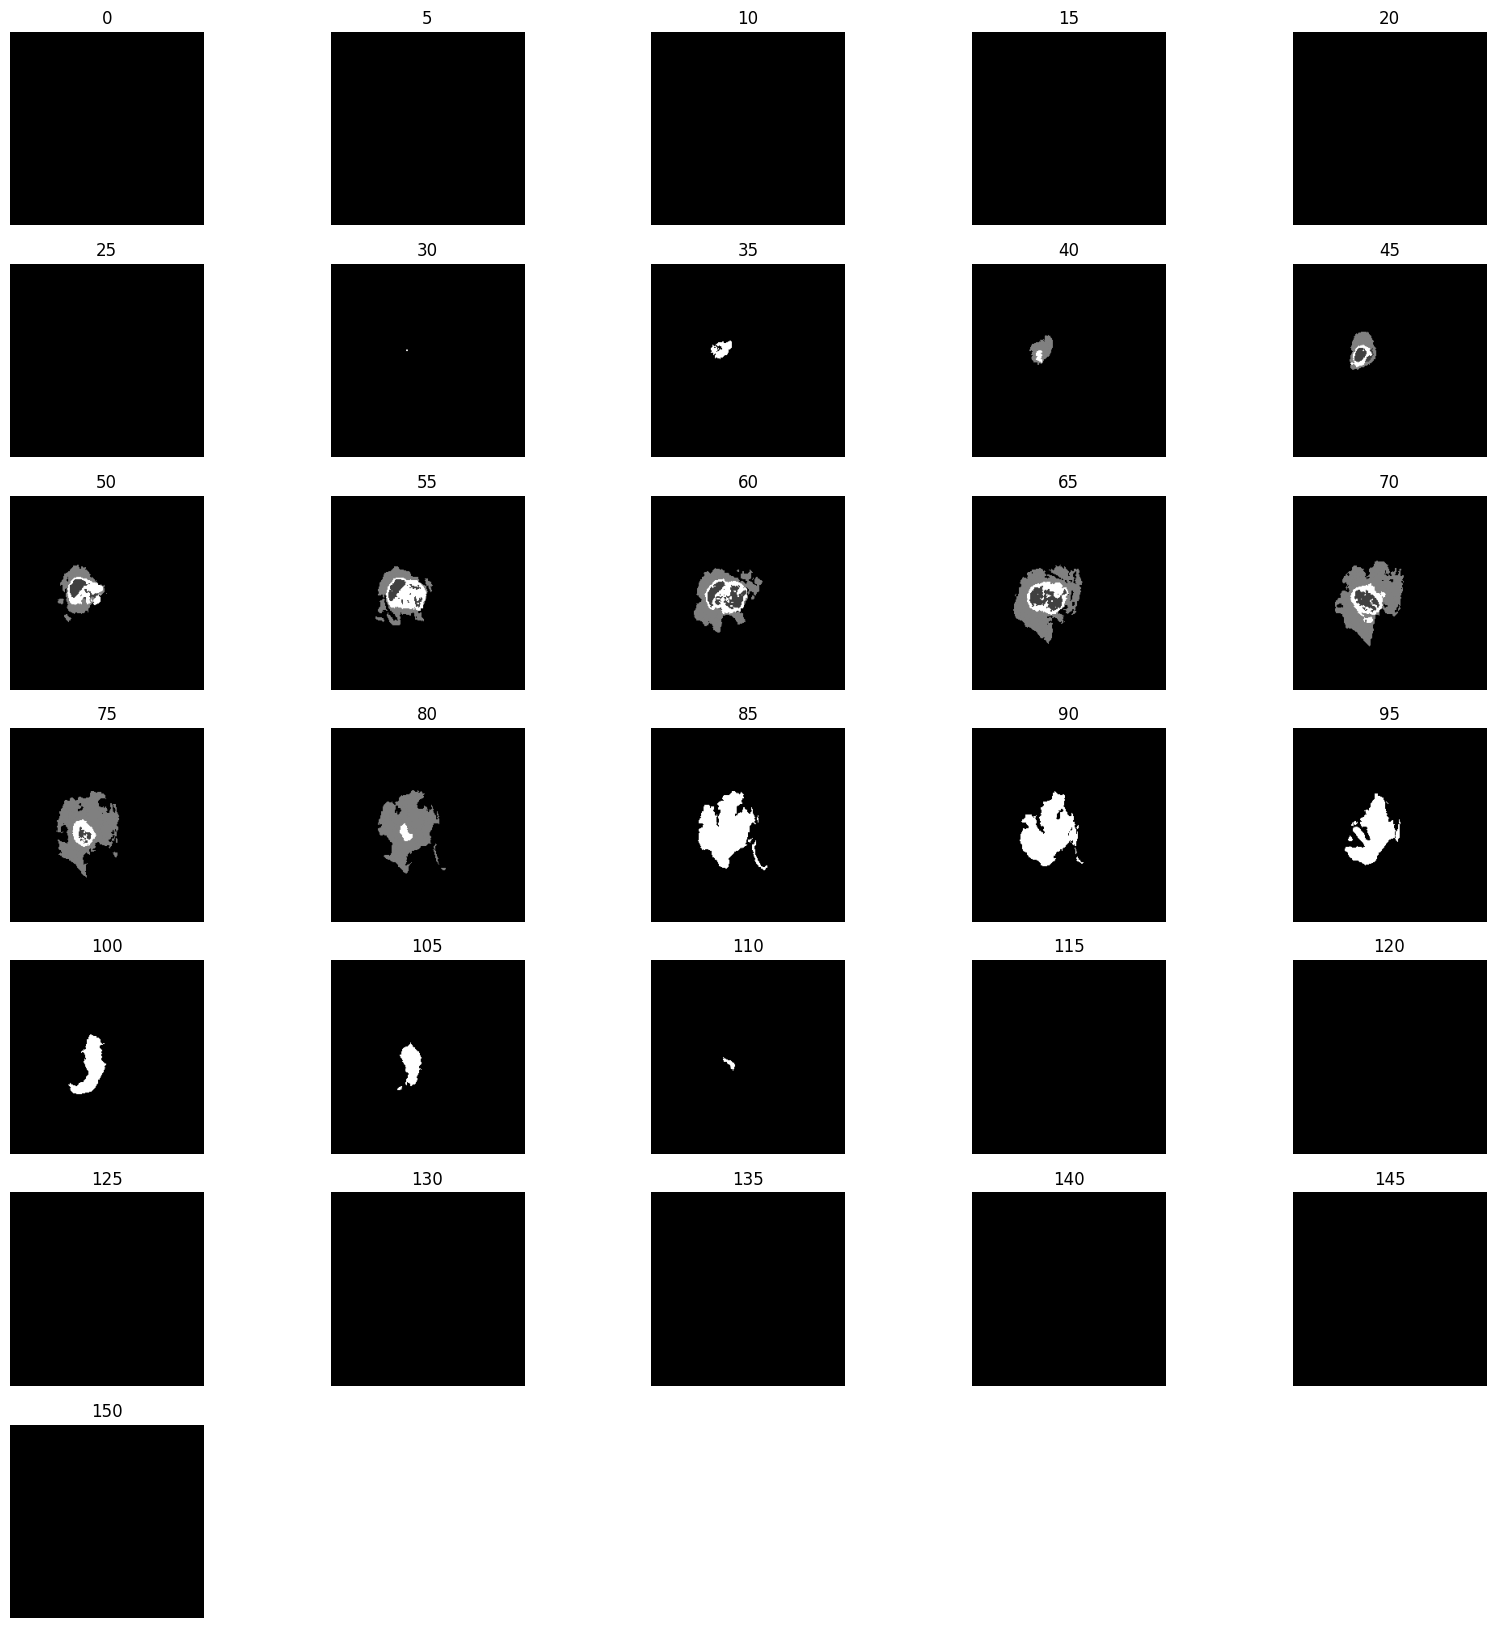

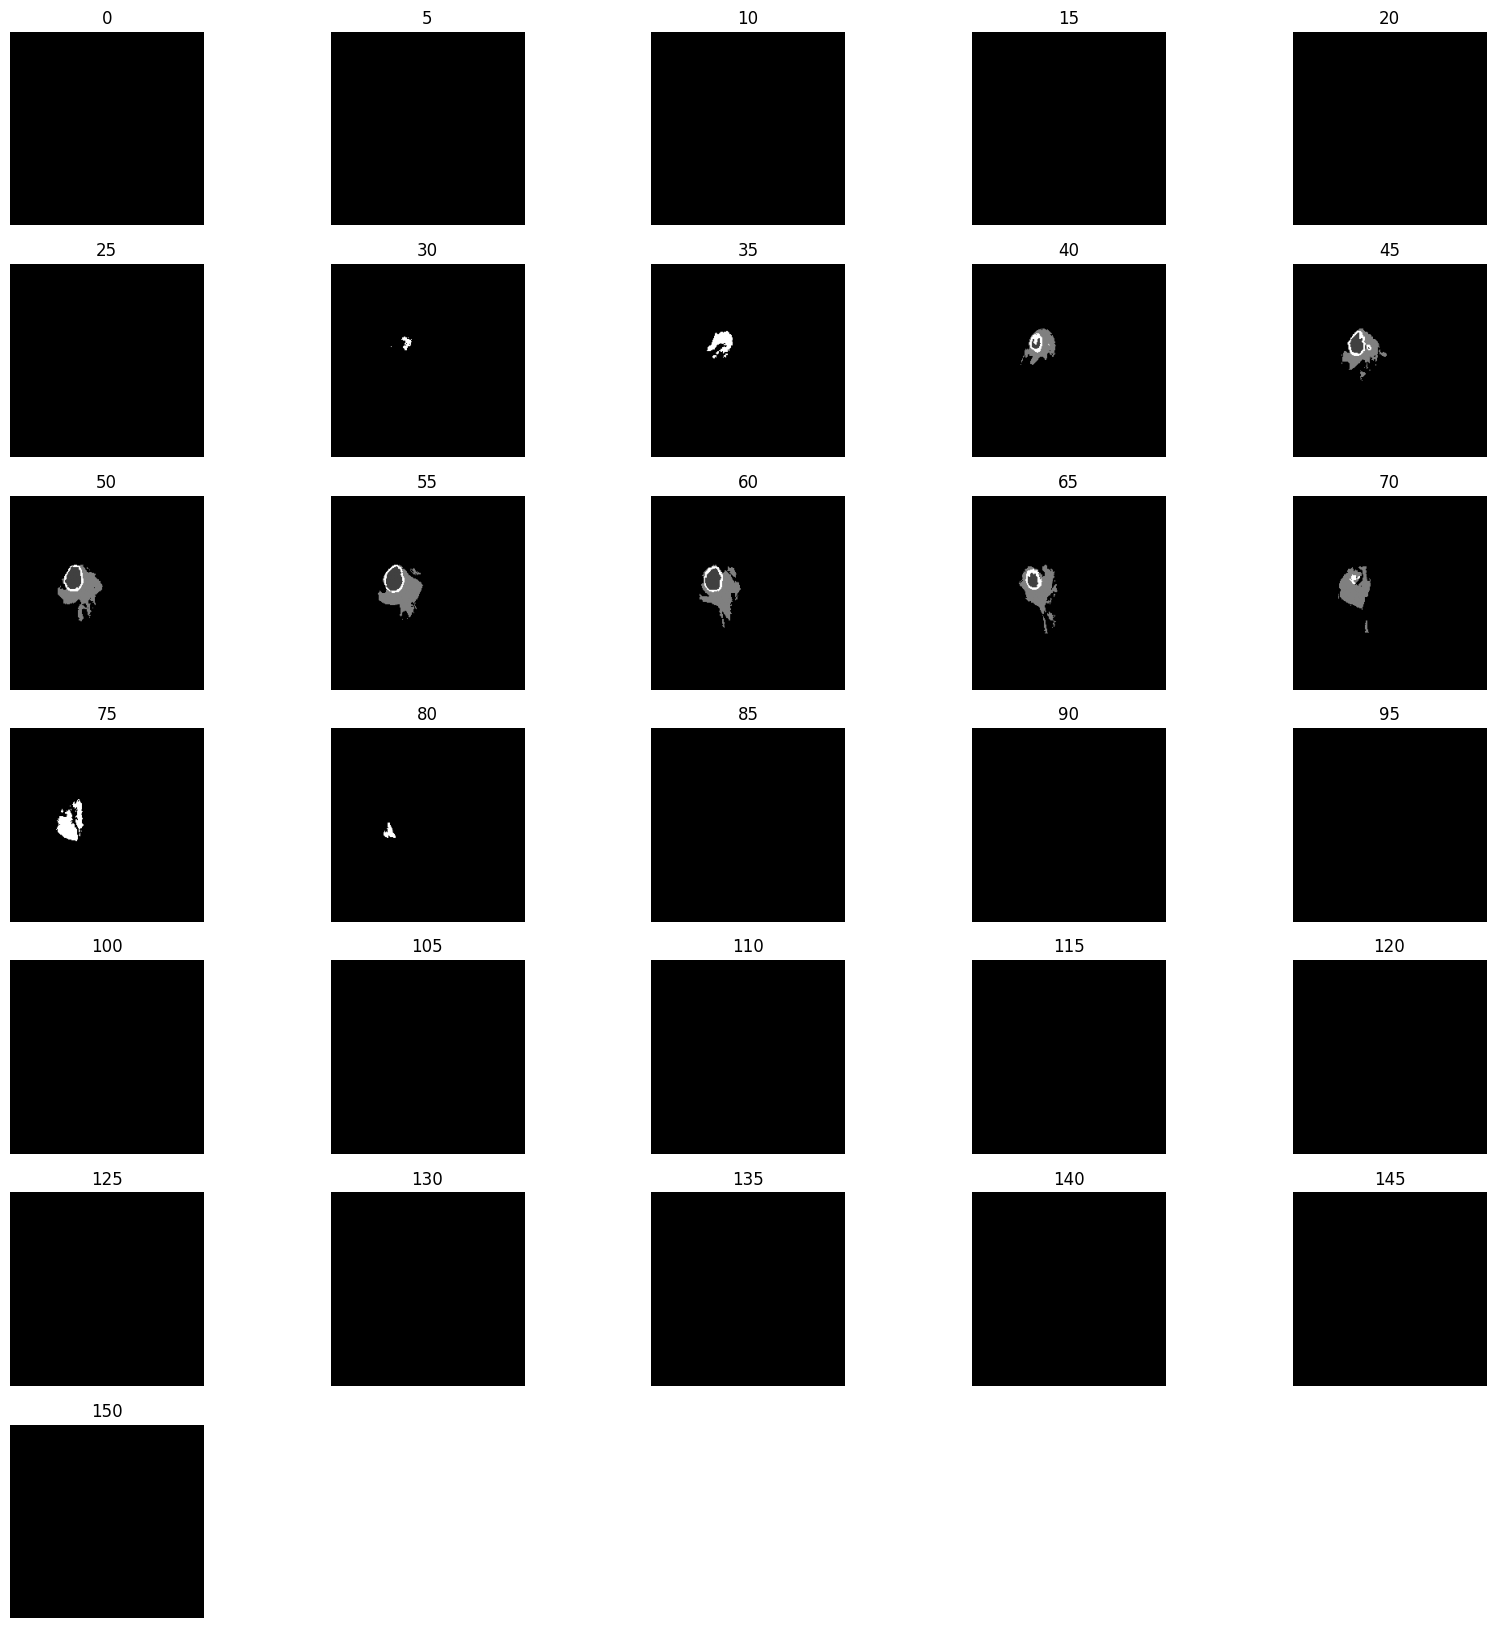

In [38]:
# TODO: Visualize the segmentation mask across all slices.
# Fill in the 'scan_type' argument with the correct string for the segmentation mask.

# For patient '001'
visualize_nifti_volume(patient_image_dict=pt_img_dict, scan_type='seg', visualize_every=5)

# Try with a few different patients to confirm the pattern:
pt_img_dict_002 = read_patient_niftis('002')
visualize_nifti_volume(patient_image_dict=pt_img_dict_002, scan_type='seg', visualize_every=5)

**Question 13 [1 point]:**
Based on your observation, what is the trade-off of using only the middle slices for training our model versus using every single slice from the 3D volume? Consider aspects like dataset size, computational efficiency, and how well the data represents the actual tumor.

Ans:

The trade-off is efficiency versus completeness. If I use only the middle slices, I keep the slices that contain most of the tumor in this patient, which reduces dataset size, lowers compute and memory cost, and removes many empty background-only slices. That is attractive for a 2D deep learning pipeline. However, I would lose some tumor extent at the beginning and end of the tumor region, because this example still has nonzero tumor roughly from slices 30 to 110. Using every slice preserves the full 3D extent of the tumor and all superior/inferior context, but it also adds many slices with no tumor at all, which increases class imbalance and makes training less efficient. Brain tumor segmentation is already known to be difficult partly because of class imbalance, so including every slice is more complete but also noisier and more expensive.